In [2]:
import pandas as pd
import plotly.express as px

In [3]:
import sys
print(sys.executable)

c:\Users\hemam\anaconda3\python.exe


In [1]:
import plotly
print(plotly.__version__)

6.8.0


In [4]:
%pip install kaleido

Note: you may need to restart the kernel to use updated packages.


In [61]:
%pip install -U plotly

  Using cached plotly-6.8.0-py3-none-any.whl.metadata (9.0 kB)
Using cached plotly-6.8.0-py3-none-any.whl (9.9 MB)
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
Note: you may need to restart the kernel to use updated packages.


In [59]:
import kaleido
print(kaleido.__version__)

c:\Users\hemam\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




AttributeError: module 'kaleido' has no attribute '__version__'

In [5]:
import pandas as pd

# 1
fund_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\01_fund_master_cleaned.csv")

# 2
nav_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\02_nav_history_cleaned.csv")

# 3
aum_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\03_aum_by_fund_house_cleaned.csv")

# 4
sip_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\raw\04_monthly_sip_inflows.csv")

# 5
category_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\05_category_inflows_cleaned.csv")

# 6
folio_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\06_industry_folio_count_cleaned.csv")

# 7
perf_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\07_scheme_performance_cleaned.csv")

# 8
txn_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\08_investor_transaction_cleaned.csv")

# 9
holding_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\09_portfolio_holdings_cleaned.csv")

# 10
benchmark_df = pd.read_csv(r"C:\Users\hemam\OneDrive\Desktop\mutual_fund_analytics\data\processed\10_benchmark_indices_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


NAV - Trend - Analysis

In [7]:
fig = px.line(
    nav_df,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend for All Mutual Fund Schemes (2022–2026)',
    labels={
        'date': 'Date',
        'nav': 'NAV',
        'amfi_code': 'Scheme'
    }
)
fig.write_image(
    "../Charts/nav_trend.png"
)
fig.show()

In [36]:
fig = px.line(
    nav_df,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend for All Mutual Fund Schemes (2022–2026)',
    labels={
        'date': 'Date',
        'nav': 'NAV',
        'amfi_code': 'Scheme'
    }
)
fig.write_image(
    "../Charts/nav_trend2.png"
)
fig.show()

In [37]:
fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    fillcolor='green',
    opacity=0.10,
    layer='below',
    line_width=0,
    annotation_text='2023 Bull Run',
    annotation_position='top left'
)
fig.write_image(
    "../Charts/nav_trend3.png"
)

In [41]:
fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    fillcolor='red',
    opacity=0.10,
    layer='below',
    line_width=0,
    annotation_text='2024 Market Correction',
    annotation_position='top left'
)
fig.write_image(
    "../Charts/nav_trend4.png"
)

In [39]:
fig.update_layout(
    width=1200,
    height=700,
    legend_title='AMFI Code',
    hovermode='x unified'
)

fig.show()
fig.write_image(
    "../Charts/nav_trend5.png"
)

## Insight 1: NAV Trend Analysis

Most mutual fund schemes exhibited strong NAV appreciation during 2023, indicating a broad market bull run. Growth moderated during 2024 during the market correction period before recovering in later years.

Supporting Chart: Daily NAV Trend for All Mutual Fund Schemes (2022–2026)

AUM GROwTH BAR CHART

In [12]:
aum_df['date'] = pd.to_datetime(aum_df['date'], dayfirst=True)

aum_df['year'] = aum_df['date'].dt.year

C:\Users\hemam\AppData\Local\Temp\ipykernel_23392\4217143580.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  aum_df['date'] = pd.to_datetime(aum_df['date'], dayfirst=True)


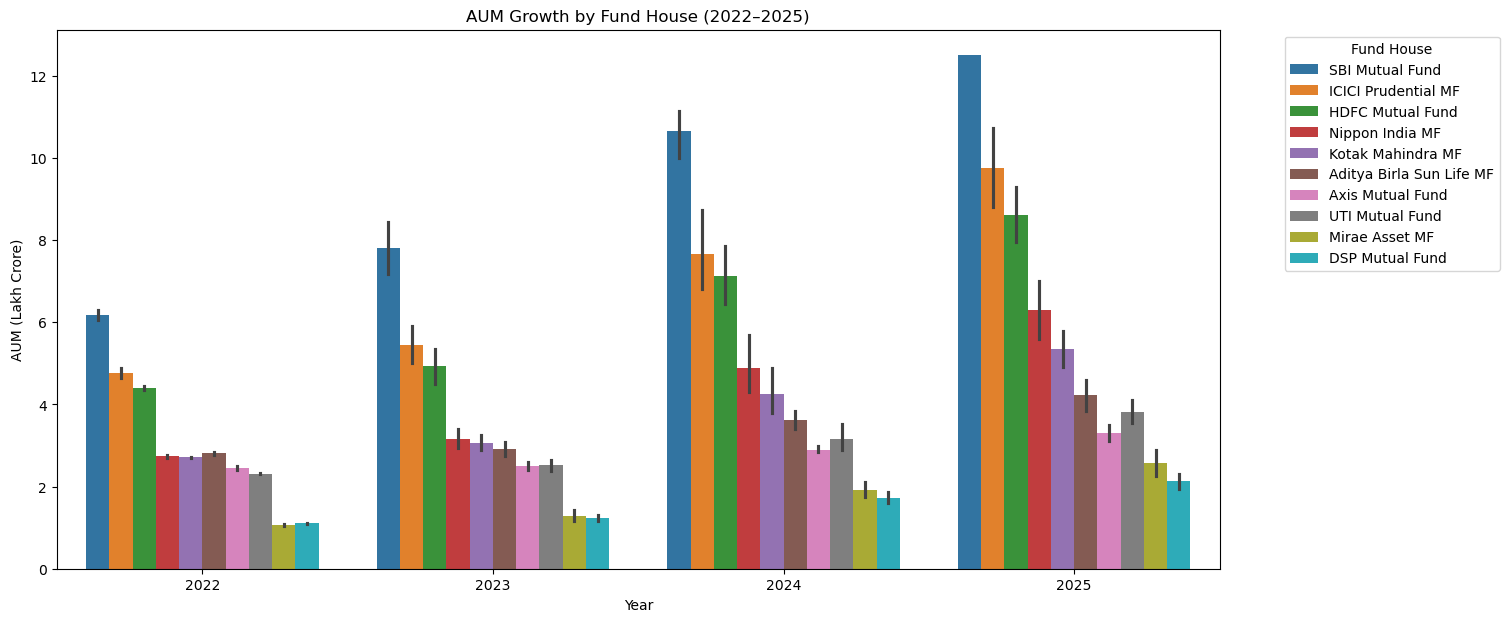

<Figure size 640x480 with 0 Axes>

In [14]:
#grouped bar
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum_df,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022–2025)')
plt.xlabel('Year')
plt.ylabel('AUM (Lakh Crore)')
plt.legend(
    title='Fund House',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()
plt.savefig("../charts/aum_growth_bar_chart.png")

In [ ]:
#highlighting SBI dominance
sbi_max = aum_df[
    aum_df['fund_house'] == 'SBI Mutual Fund'
]['aum_lakh_crore'].max()

print(sbi_max)

12.5


## Insight 2: AUM Growth by Fund House

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses from 2022 to 2025. The overall AUM of major fund houses increased steadily during the period, reflecting strong growth in the mutual fund industry and increasing investor participation.

Supporting Chart: AUM Growth by Fund House (2022–2025)

SIP INFLOW TIME SERIES

In [43]:
sip_df = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

sip_df['month'] = pd.to_datetime(sip_df['month'])

print(sip_df.head())
print(sip_df.columns.tolist())

       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [44]:
#CREATE PLOTY TIME SERIES
import plotly.express as px

fig = px.line(
    sip_df,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)',
    markers=True
)
fig.show()
fig.write_image(
    "../Charts/sip_inflow_time_series.png"
)

In [45]:
#ANNOTATE 31,002CR PEAK
fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='₹31,002 Cr All-Time High',
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-40
)
fig.write_image(
    "../Charts/sip_inflow_time_series2.png"
)


In [19]:
#IMPROVE LAYOUT 
fig.update_layout(
    xaxis_title='Month',
    yaxis_title='SIP Inflow (₹ Crore)',
    hovermode='x unified',
    width=1200,
    height=600
)

fig.show()

## Insight 3: SIP Inflow Trend Analysis

Monthly SIP inflows increased steadily from 2022 to 2025, reflecting growing participation of retail investors in mutual funds. The highest SIP inflow of ₹31,002 crore was recorded in December 2025, demonstrating strong investor confidence and the increasing preference for systematic investing.

Supporting Chart: Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)

CATEGORY INFLOW HEATMAP

In [17]:
#CATEGORY INFLOW HEATMAP
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
#CREATE PIVOT TABLE
pivot_df = category_df.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

print(pivot_df.head())

month            2024-04-01  2024-05-01  2024-06-01  2024-07-01  2024-08-01  \
category                                                                      
ELSS                  466.0       553.0       472.0       471.0       499.0   
Flexi Cap            4947.0      5529.0      4478.0      4869.0      5562.0   
Gilt                  784.0       836.0       864.0       959.0       952.0   
Hybrid               2955.0      3487.0      3163.0      3291.0      3684.0   
Large & Mid Cap      4214.0      4368.0      4610.0      5023.0      5411.0   

month            2024-09-01  2024-10-01  2024-11-01  2024-12-01  2025-01-01  \
category                                                                      
ELSS                  537.0       537.0       571.0       521.0       516.0   
Flexi Cap            5397.0      6004.0      6111.0      4654.0      5603.0   
Gilt                  925.0       898.0       704.0       831.0       744.0   
Hybrid               3015.0      3314.0      3264.0

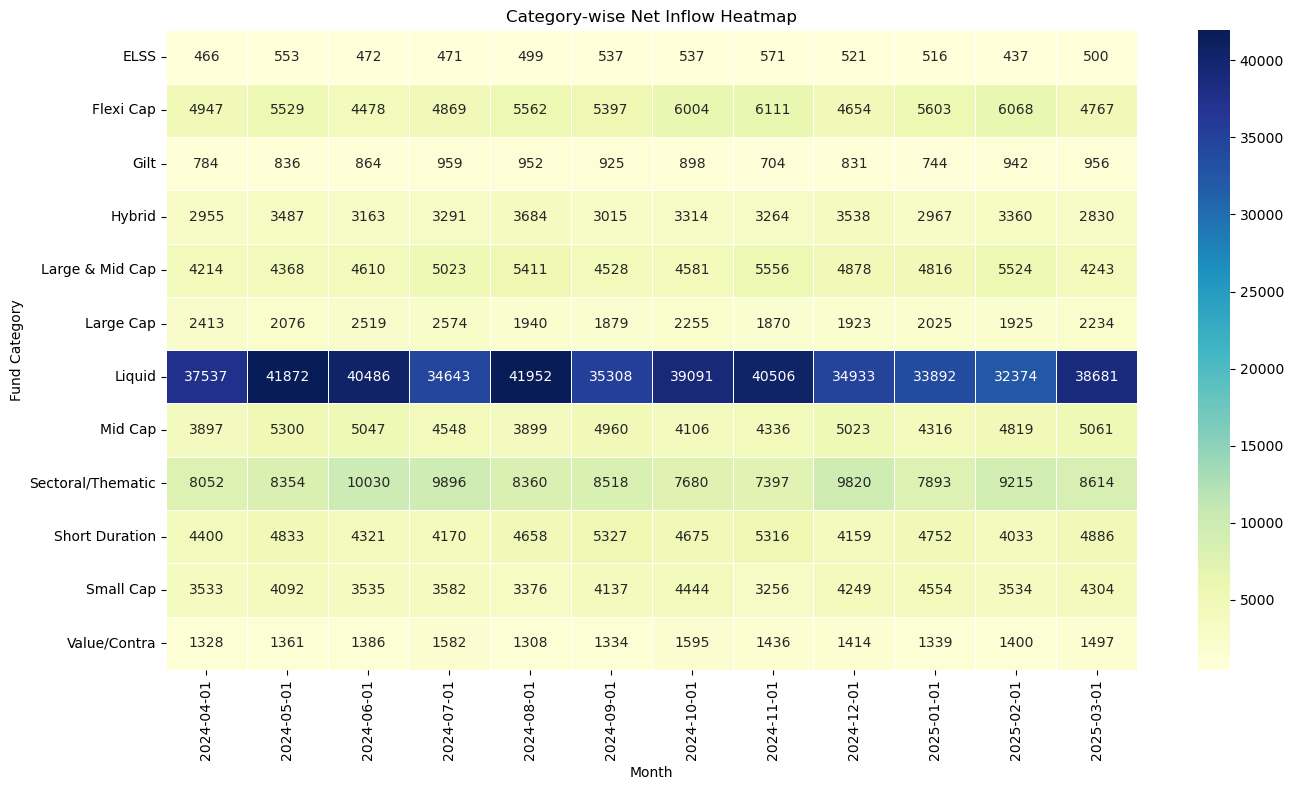

<Figure size 640x480 with 0 Axes>

In [19]:
#PLOT HEATMAP
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_df,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f',
    linewidths=0.5
)

plt.title(
    'Category-wise Net Inflow Heatmap'
)

plt.xlabel('Month')
plt.ylabel('Fund Category')

plt.tight_layout()

plt.show()
plt.savefig("../charts/category_inflow.png")

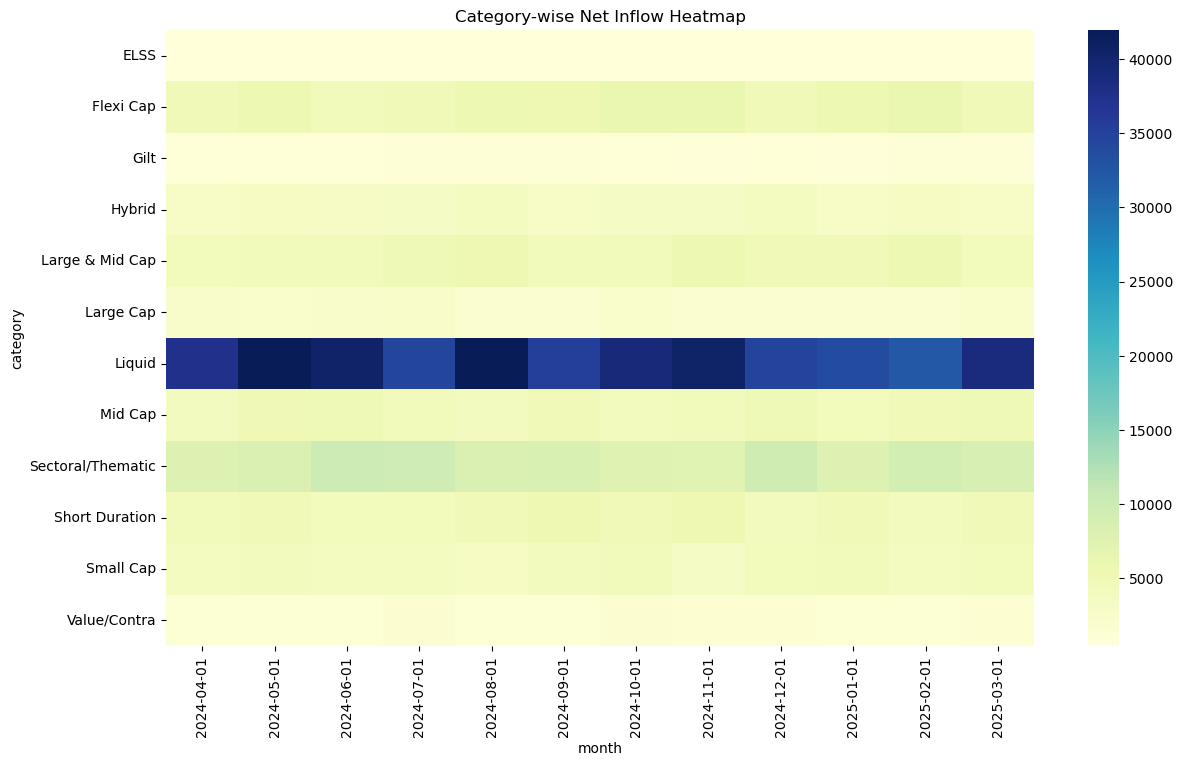

In [24]:
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_df,
    cmap='YlGnBu',
    annot=False
)

plt.title(
    'Category-wise Net Inflow Heatmap'
)

plt.savefig(
    "../reports/category_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Insight 4: Category-wise Net Inflow Analysis

Liquid Funds consistently attracted the highest net inflows across most months, indicating strong investor preference for short-term liquidity and low-risk investments. Sectoral/Thematic Funds and Flexi Cap Funds also recorded significant inflows, reflecting growing investor interest in diversified and thematic investment opportunities.

Supporting Chart: Category-wise Net Inflow Heatmap

INVESTORS DEMOGRAPHICS

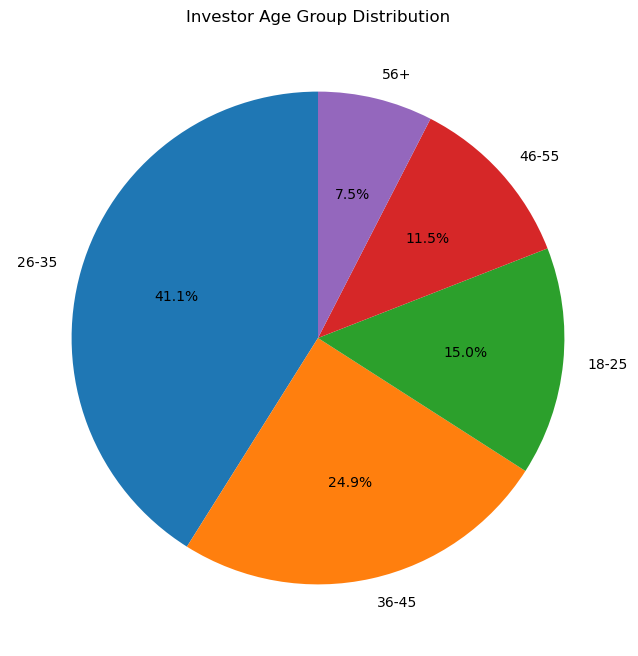

<Figure size 640x480 with 0 Axes>

In [21]:
#AGE GROUP DISTRIBUTION PIE CHART
import matplotlib.pyplot as plt

age_counts = txn_df['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Investor Age Group Distribution')

plt.show()
plt.savefig("../charts/investor_demographic1.png")

## Insight 5: Investor Age Group Distribution

The 26–35 age group accounted for the largest share of mutual fund investors, indicating strong participation from young professionals who are increasingly adopting long-term investment strategies.

Supporting Chart: Investor Age Group Distribution

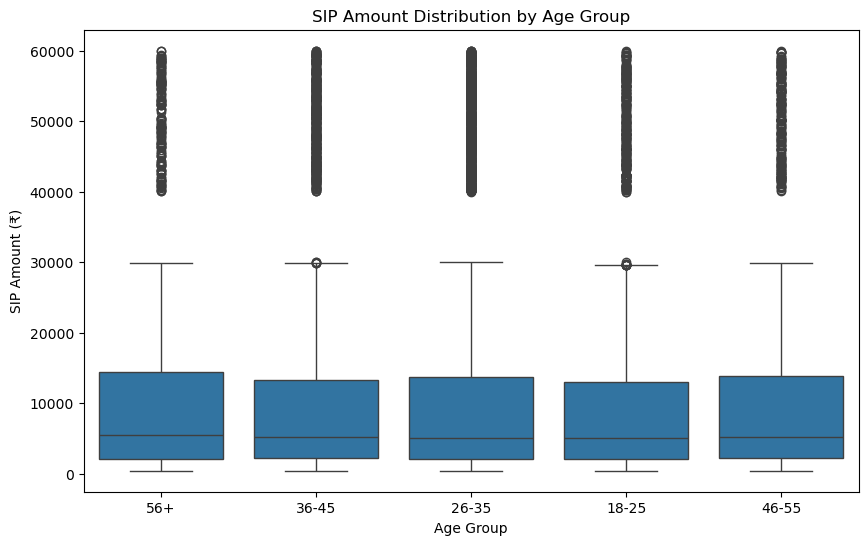

<Figure size 640x480 with 0 Axes>

In [22]:
#SIP AMOUNT BOX PLOT BY AGE GROUP
import seaborn as sns
import matplotlib.pyplot as plt

sip_df = txn_df[
    txn_df['transaction_type'] == 'SIP'
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_df,
    x='age_group',
    y='amount_inr'
)

plt.title(
    'SIP Amount Distribution by Age Group'
)

plt.xlabel('Age Group')
plt.ylabel('SIP Amount (₹)')

plt.show()
plt.savefig("../charts/investor_demographic2.png")

## Insight: SIP Amount by Age Group

The distribution of SIP amounts varied across age groups, with older investors generally exhibiting higher investment amounts and greater variability, reflecting higher earning capacity and investment experience.

Supporting Chart: SIP Amount Distribution by Age Group

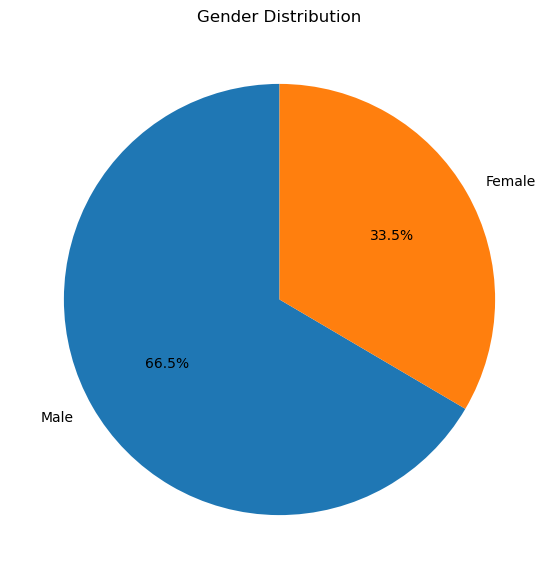

<Figure size 640x480 with 0 Axes>

In [23]:
#GENDER SPLIT PIE CHART
gender_counts = txn_df['gender'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Gender Distribution')

plt.show()
plt.savefig("../charts/investor demographic3.png")

## Insight 6: Gender Distribution

Male investors represented a larger share of the investor base, although female participation remained significant, indicating increasing financial awareness and investment adoption across genders.

Supporting Chart: Gender Distribution

GEOGRAPHICAL DISTRIBUTION

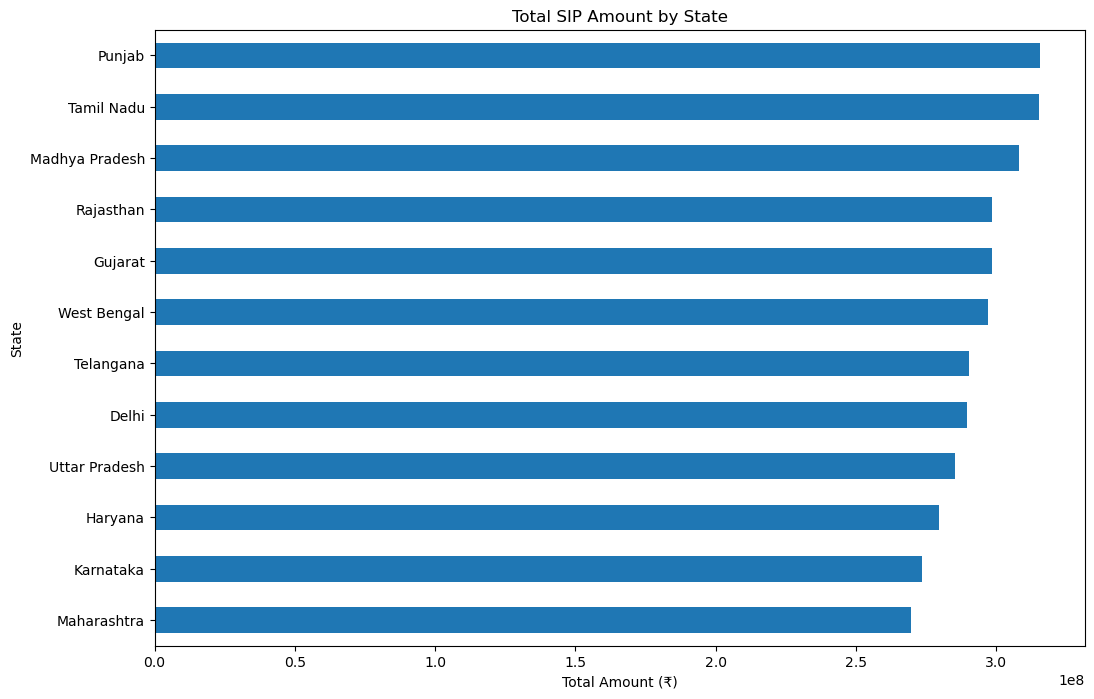

<Figure size 640x480 with 0 Axes>

In [24]:
#SIP AMOOUNT BY STATE(HORIZONTAL BAR CHART)
state_sip = (
    txn_df.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_sip.plot(kind='barh')

plt.title(
    'Total SIP Amount by State'
)

plt.xlabel('Total Amount (₹)')
plt.ylabel('State')

plt.show()
plt.savefig("../charts/geographical_distributuion1.png")

## Insight 7: Geographic Distribution by State

SIP investments were concentrated in a few major states, indicating stronger mutual fund penetration and higher investor participation in economically developed regions. The leading states contributed a significant share of total investment inflows.

Supporting Chart: Total SIP Amount by State

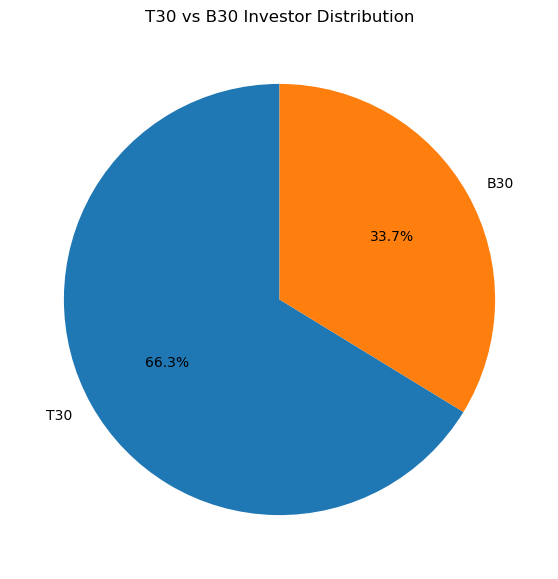

<Figure size 640x480 with 0 Axes>

In [25]:
#T30 VS B30 CITY TIER PIE CHART
city_counts = txn_df['city_tier'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'T30 vs B30 Investor Distribution'
)

plt.show()
plt.savefig("../charts/geographical_distribution2.png")

## Insight 8: T30 vs B30 City Distribution

T30 cities accounted for the majority of mutual fund investors, reflecting stronger awareness, accessibility, and adoption of investment products in metropolitan areas. However, B30 cities also contributed meaningfully, indicating expanding mutual fund penetration beyond major urban centers.

Supporting Chart: T30 vs B30 Investor Distribution

FOLIO COUNT GROWTH

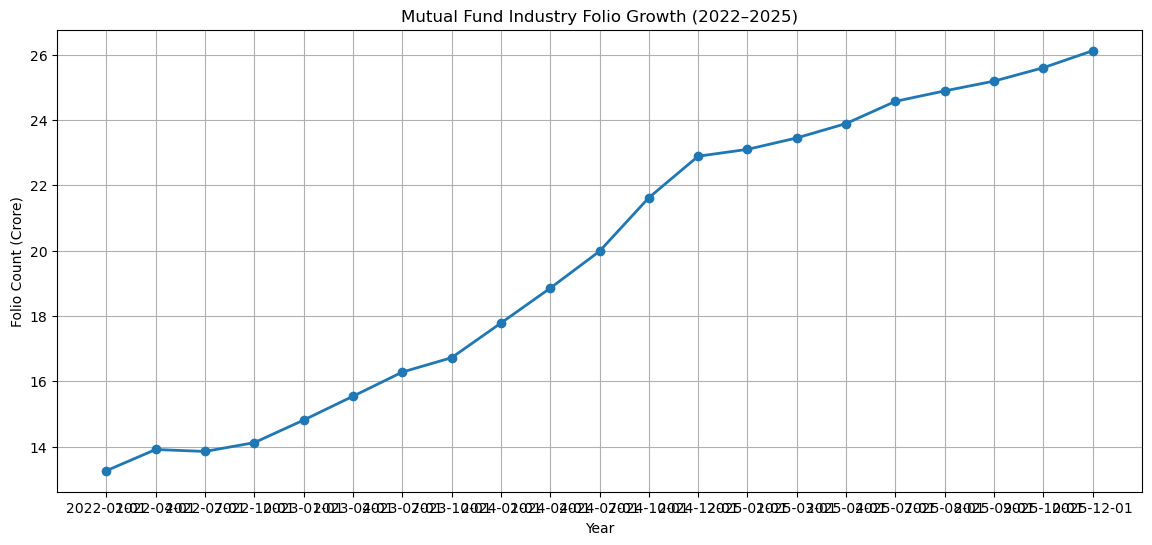

In [26]:
#CREATE FOLIO GROWTH LINE CHART
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    folio_df['month'],
    folio_df['total_folios_crore'],
    marker='o',
    linewidth=2
)

plt.title(
    'Mutual Fund Industry Folio Growth (2022–2025)'
)

plt.xlabel('Year')
plt.ylabel('Folio Count (Crore)')
plt.grid(True)
plt.savefig("../charts/folio_growth1.png")

## Insight 9: Mutual Fund Folio Growth

Mutual fund folio counts nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, representing approximately 97% growth. This substantial increase reflects rising retail investor participation and growing awareness of mutual fund investments across India.

Supporting Chart: Mutual Fund Industry Folio Growth (2022–2025)

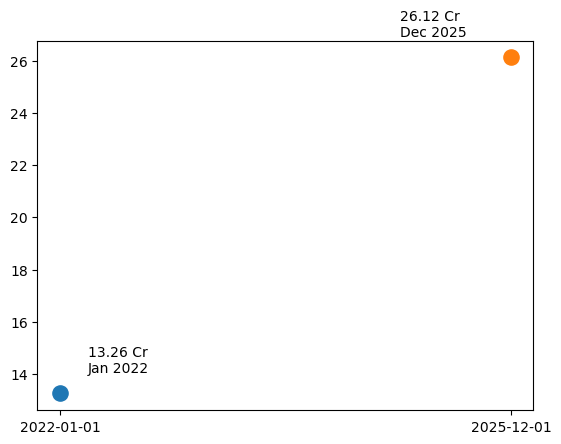

In [27]:
#MARK KEY MILESTONES
start = folio_df.iloc[0]
end = folio_df.iloc[-1]

plt.scatter(
    start['month'],
    start['total_folios_crore'],
    s=120
)

plt.scatter(
    end['month'],
    end['total_folios_crore'],
    s=120
)

plt.annotate(
    '13.26 Cr\nJan 2022',
    (
        start['month'],
        start['total_folios_crore']
    ),
    xytext=(20,15),
    textcoords='offset points'
)

plt.annotate(
    '26.12 Cr\nDec 2025',
    (
        end['month'],
        end['total_folios_crore']
    ),
    xytext=(-80,15),
    textcoords='offset points'
)
plt.savefig("../charts/folio_growth2.png")

In [36]:
growth = (
    (end['total_folios_crore'] -
     start['total_folios_crore'])
    /
    start['total_folios_crore']
) * 100

print(
    f"Growth: {growth:.1f}%"
)
plt.tight_layout()
plt.show()

Growth: 97.0%


<Figure size 640x480 with 0 Axes>

NAV RETURN CORRELATION MATRIX

In [29]:
#SELECT 10 FUNDS
top_10_funds = (
    nav_df['amfi_code']
    .unique()[:10]
)

nav_10 = nav_df[
    nav_df['amfi_code'].isin(top_10_funds)
]

In [30]:
#NAV PIVOT TABLE 
nav_df['date'] = pd.to_datetime(nav_df['date'])

top_10_funds = nav_df['amfi_code'].unique()[:10]

nav_10 = nav_df[
    nav_df['amfi_code'].isin(top_10_funds)
]

nav_pivot = nav_10.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

print(nav_pivot.head())

amfi_code     100016   100025    100033    101206   101207    101208   102885  \
date                                                                            
2022-01-03  520.4608  26.3169  107.3758  305.0996  38.5736  310.7415  89.8728   
2022-01-04  515.0971  26.2234  105.9447  305.4514  38.1545  310.6977  90.8724   
2022-01-05  521.7239  26.2221  105.4800  306.6324  38.1775  310.8165  90.1565   
2022-01-06  515.7880  26.1728  104.9350  305.9800  37.0665  310.7719  91.5338   
2022-01-07  515.1639  26.2261  104.3318  304.0480  37.9845  310.8388  90.6762   

amfi_code     102886    102887   118632  
date                                     
2022-01-03  119.2905  191.0721  42.8339  
2022-01-04  120.6402  189.0737  42.8033  
2022-01-05  121.4580  188.0701  43.0564  
2022-01-06  125.2386  190.4545  43.2088  
2022-01-07  124.1321  187.3124  42.9585  


In [31]:
#DAILY RETURNS 
returns = nav_pivot.pct_change()
returns = returns.dropna()
print(returns.head())

amfi_code     100016    100025    100033    101206    101207    101208  \
date                                                                     
2022-01-04 -0.010306 -0.003553 -0.013328  0.001153 -0.010865 -0.000141   
2022-01-05  0.012865 -0.000050 -0.004386  0.003866  0.000603  0.000382   
2022-01-06 -0.011377 -0.001880 -0.005167 -0.002128 -0.029101 -0.000143   
2022-01-07 -0.001210  0.002036 -0.005748 -0.006314  0.024766  0.000215   
2022-01-10 -0.008639  0.006791  0.006277  0.011548  0.001251  0.000690   

amfi_code     102885    102886    102887    118632  
date                                                
2022-01-04  0.011122  0.011314 -0.010459 -0.000714  
2022-01-05 -0.007878  0.006779 -0.005308  0.005913  
2022-01-06  0.015277  0.031127  0.012678  0.003540  
2022-01-07 -0.009369 -0.008835 -0.016498 -0.005793  
2022-01-10 -0.001202 -0.000722 -0.011593  0.006360  


In [32]:
#COMPUTE DAILY RETURNS
#RETURN =NAV(T)-NAV(T-1)
#        ---------------
#        NAV(T-1)
corr_matrix = returns.corr()
print(corr_matrix)

amfi_code    100016    100025    100033    101206    101207    101208  \
amfi_code                                                               
100016     1.000000  0.045567 -0.000006  0.027747  0.016053 -0.033773   
100025     0.045567  1.000000  0.002150  0.023769 -0.006710  0.018455   
100033    -0.000006  0.002150  1.000000 -0.018079  0.000351  0.007864   
101206     0.027747  0.023769 -0.018079  1.000000  0.010202 -0.027230   
101207     0.016053 -0.006710  0.000351  0.010202  1.000000 -0.007530   
101208    -0.033773  0.018455  0.007864 -0.027230 -0.007530  1.000000   
102885    -0.093533 -0.001038 -0.034228  0.001570 -0.005929 -0.001436   
102886    -0.005867  0.013754 -0.018166  0.007229  0.004860  0.014307   
102887    -0.023316 -0.005648 -0.036647 -0.006490  0.002304  0.036547   
118632    -0.026781 -0.014166 -0.013318 -0.005432  0.043384  0.003507   

amfi_code    102885    102886    102887    118632  
amfi_code                                          
100016    -0.093533

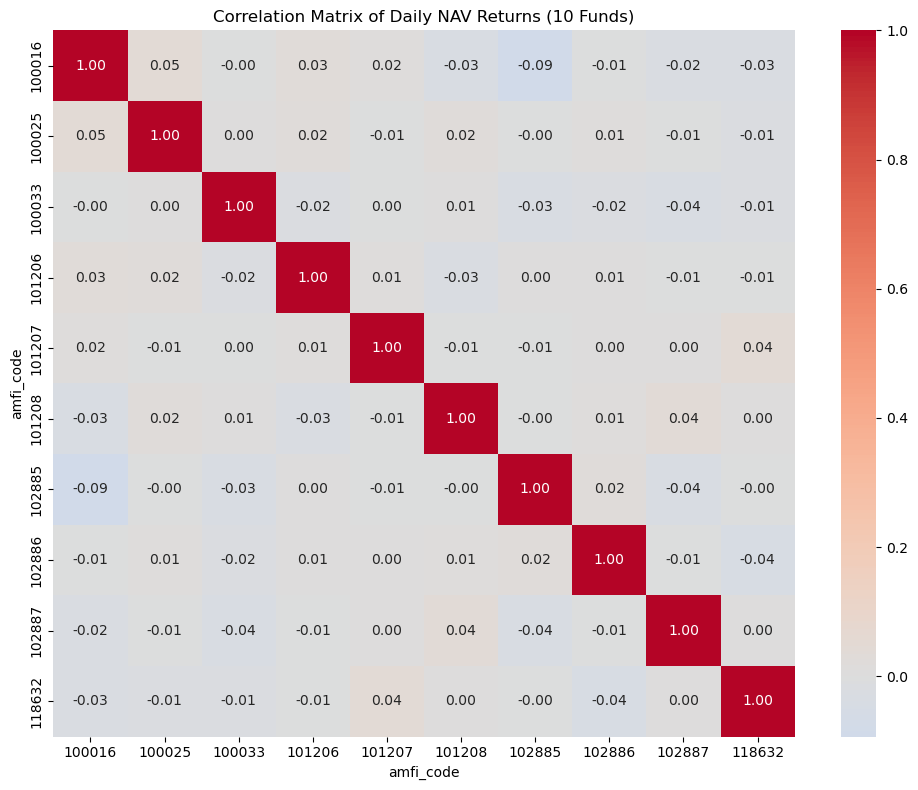

<Figure size 640x480 with 0 Axes>

In [33]:
#SEABORN HEATMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title(
    'Correlation Matrix of Daily NAV Returns (10 Funds)'
)

plt.tight_layout()

plt.show()
plt.savefig("../charts/nav_return_correlation.png")

## Insight: NAV Return Correlation Analysis

Most mutual fund schemes exhibited strong positive correlations in their daily NAV returns, indicating that fund performance was largely influenced by broader market movements

Supporting Chart: Correlation Matrix of Daily NAV Returns (10 Funds)

SECTOR ALLOCATION DONUT CHART

In [34]:
#AGGREGATE SECTOR WEIGHTS
sector_df = (
    holding_df.groupby('sector')['weight_pct']
    .sum()
    .reset_index()
)

sector_df = sector_df.sort_values(
    'weight_pct',
    ascending=False
)

print(sector_df.head())

        sector  weight_pct
1      Banking      652.26
7           IT      455.47
11      Pharma      407.45
0   Automobile      323.65
13   Utilities      265.54


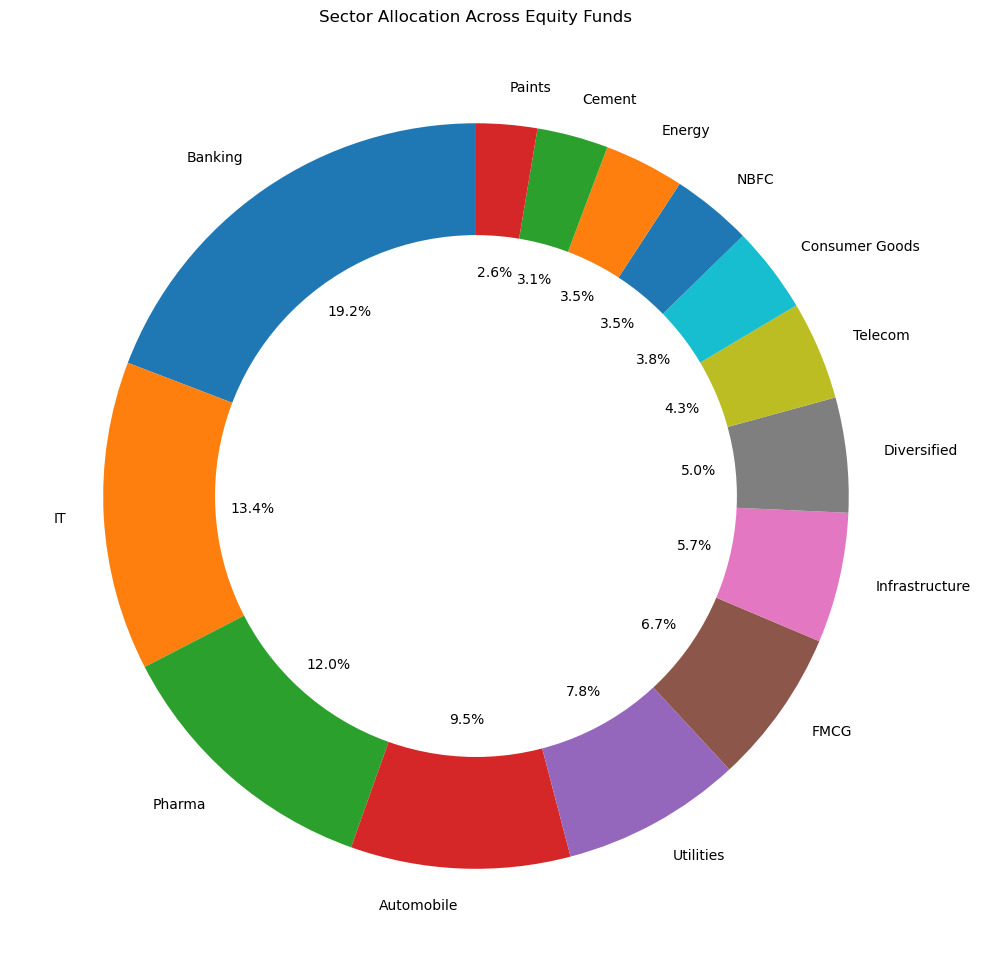

<Figure size 640x480 with 0 Axes>

In [35]:
#CREATE DONUT CHART
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.pie(
    sector_df['weight_pct'],
    labels=sector_df['sector'],
    autopct='%1.1f%%',
    startangle=90
)

# Create donut hole
centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(
    centre_circle
)

plt.title(
    'Sector Allocation Across Equity Funds'
)

plt.tight_layout()

plt.show()
plt.savefig("../charts/sector_allocation_donut.png")

## Insight 10: Sector Allocation Analysis

Banking, Information Technology, and Financial Services sectors dominated portfolio allocations, while most equity funds exhibited strong positive correlations in daily NAV returns.

Supporting Chart: Sector Allocation Across Equity Funds